# DDXPlus Stopping-Policy Ablation

This notebook tests whether hybrid v1 improves evidence efficiency because the partial-evidence MLP provides a better stopping signal, or whether a more aggressive LLM-only stop policy can achieve the same request/accuracy tradeoff.

This is an **offline replay** notebook. It does not call an LLM API. It replays saved notebook `08` traces, reconstructs turn-level states, runs the local partial-evidence MLP at each turn, and compares stopping rules at matched evidence budgets.

Replay limitation: this can test different stop points along already-recorded evidence trajectories. It cannot test how the LLM would choose different future questions if a different stopping policy changed the conversation.

In [1]:
from __future__ import annotations

import ast
import json
import math
import os
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import f1_score
from torch import nn

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 40)

ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "scripts" / "download_ddxplus.py").exists()),
    Path.cwd(),
)
DATASET_DIR = ROOT / "dataset" if (ROOT / "dataset").exists() else ROOT / ".data" / "ddxplus" / "22687585"

RUN_NAME = "stopping_policy_ablation_24case_v1"
ARTIFACT_ROOT = ROOT / "artifacts" / "stopping_policy_ablation" / RUN_NAME
FIGURE_DIR = ARTIFACT_ROOT / "figures"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MAIN_REPLAY_DIR = ROOT / "artifacts" / "sequential_single_agent_cost_sensitive" / "single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1" / "lambda_0p100"
OBSERVED_NB08_RUN_DIR = ROOT / "artifacts" / "sequential_single_agent_cost_sensitive" / "single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1"
HYBRID_REFERENCE_RUN_DIR = ROOT / "artifacts" / "sequential_hybrid_mlp_feedback" / "hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1"
PARTIAL_MODEL_SELECTED_PATH = ROOT / "artifacts" / "one_shot_partial_evidence" / "selected_model.json"
TARGET_MEAN_REQUESTS = 7.5
RANDOM_SEED = 2919

print("Project root        :", ROOT)
print("Dataset dir         :", DATASET_DIR)
print("Main replay dir     :", MAIN_REPLAY_DIR)
print("Notebook 08 run dir :", OBSERVED_NB08_RUN_DIR)
print("Hybrid reference dir:", HYBRID_REFERENCE_RUN_DIR)
print("Artifact root       :", ARTIFACT_ROOT)

Project root        : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir         : /Users/bilalawan/claw/assignments/baseline_model/dataset
Main replay dir     : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1/lambda_0p100
Notebook 08 run dir : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1
Hybrid reference dir: /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1
Artifact root       : /Users/bilalawan/claw/assignments/baseline_model/artifacts/stopping_policy_ablation/stopping_policy_ablation_24case_v1


## Dataset, Encoding, And Local Model Utilities

The replay notebook uses the same BASD-style slot encoding as the earlier one-shot and hybrid notebooks. The MLP receives only the evidence roots visible at the candidate stopping turn.

In [2]:
REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_test_patients.zip",
]


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def ensure_dataset_present(dataset_dir: Path) -> dict[str, Path]:
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing dataset files in {dataset_dir}: {missing}")
    return paths


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        member = next((name for name in members if name.endswith(".csv")), members[0])
        with archive.open(member) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    frame = frame.copy()
    frame["source_row_index"] = np.arange(len(frame), dtype=int)
    frame["split"] = split_name
    frame["case_id"] = split_name + ":" + frame["source_row_index"].astype(str)
    return frame


def safe_parse_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    text = str(raw).strip()
    if text == "" or text.lower() == "nan":
        return []
    try:
        parsed = json.loads(text)
    except Exception:
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            return [text]
    if isinstance(parsed, list):
        return parsed
    return [parsed]


def parse_evidence_token(token: str) -> tuple[str, str | None]:
    token = str(token)
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


def encode_age(age: int) -> int:
    age = int(age)
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    sex = str(sex)
    if sex == "M":
        return 0
    if sex == "F":
        return 1
    raise ValueError(f"Unexpected sex value: {sex}")


@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    question_text: dict[str, str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, evidence_metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(evidence_metadata.keys())
        slot_slices = {}
        data_types = {}
        possible_values = {}
        default_values = {}
        categorical_integer_roots = set()
        question_text = {}
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id in root_ids:
            meta = evidence_metadata[root_id]
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            question_text[root_id] = meta.get("question_en", root_id)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(root_ids, slot_slices, data_types, possible_values, default_values, categorical_integer_roots, question_text, feature_names)

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(int(age))] = 1.0
        state[8 + encode_sex(str(sex))] = 1.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        if root_id not in self.slot_slices:
            return state
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = -1.0
            else:
                possible = self.possible_values[root_id]
                denominator = max(1, len(possible) - 1)
                state[start] = float(possible.index(str(chosen))) / denominator if str(chosen) in possible else -1.0
            return state
        state[start:end] = -1.0
        if values:
            for value in values:
                if value in self.possible_values[root_id]:
                    state[start + self.possible_values[root_id].index(value)] = 1.0
        return state


def row_evidence_by_root(row: dict[str, Any]) -> dict[str, list[str]]:
    evidence_by_root: dict[str, list[str]] = {}
    for token in safe_parse_list(row.get("EVIDENCES", [])):
        root_id, value = parse_evidence_token(str(token))
        evidence_by_root.setdefault(root_id, [])
        evidence_by_root[root_id].append("present" if value is None else str(value))
    return evidence_by_root


def initial_revealed_roots(row: dict[str, Any]) -> dict[str, list[str]]:
    evidence_by_root = row_evidence_by_root(row)
    revealed: dict[str, list[str]] = {}
    for token in safe_parse_list(row.get("INITIAL_EVIDENCE", [])):
        root_id, value = parse_evidence_token(str(token))
        if value is not None:
            revealed[root_id] = [str(value)]
        else:
            revealed[root_id] = evidence_by_root.get(root_id, ["present"])
    return revealed


def values_from_reveal_payload(payload: dict[str, Any] | None) -> tuple[str | None, list[str]]:
    if not payload:
        return None, []
    root_id = payload.get("root_evidence_id")
    if root_id is None:
        return None, []
    if payload.get("status") == "absent":
        return str(root_id), []
    values = [str(value) for value in payload.get("revealed_values", []) if value is not None]
    if not values:
        for token in payload.get("revealed_tokens", []) or []:
            _, value = parse_evidence_token(str(token))
            values.append("present" if value is None else str(value))
    if not values and payload.get("status") == "present":
        values = ["present"]
    return str(root_id), values


def encode_state_from_roots(row: dict[str, Any], revealed_roots: dict[str, list[str]]) -> np.ndarray:
    state = schema.initial_state(int(row["AGE"]), str(row["SEX"]))
    evidence_by_root = row_evidence_by_root(row)
    for root_id in sorted(revealed_roots.keys()):
        values = list(revealed_roots.get(root_id, []))
        if values == ["present"]:
            values = evidence_by_root.get(root_id, ["present"])
        schema.apply_root_observation(state, root_id, values)
    return state


class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))


def load_partial_mlp(model_dir: Path, schema: ObservationSchema) -> tuple[nn.Module, list[str], dict[str, Any]]:
    checkpoint = torch.load(model_dir / "best_model.pt", map_location="cpu")
    resolved = checkpoint.get("resolved_run_config", {})
    labels = list(checkpoint.get("label_names", []))
    if not labels:
        raise ValueError("Checkpoint does not contain label_names")
    hidden_sizes = list(resolved.get("hidden_sizes", [2048, 2048, 2048]))
    dropout = float(resolved.get("dropout", 0.0))
    model = DirectDiagnosisMLP(schema.feature_size, hidden_sizes, len(labels), dropout=dropout)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, labels, resolved


def predict_mlp_feedback(model: nn.Module, labels: list[str], features: np.ndarray, previous_top1: str | None = None, previous_stability: int = 0) -> dict[str, Any]:
    with torch.no_grad():
        logits = model(torch.tensor(features[None, :], dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    order = np.argsort(probs)[::-1]
    top_indices = order[:5]
    top_predictions = [labels[idx] for idx in top_indices]
    top_probabilities = [float(probs[idx]) for idx in top_indices]
    confidence = top_probabilities[0]
    second = top_probabilities[1] if len(top_probabilities) > 1 else 0.0
    entropy = float(-(probs * np.log(probs + 1e-12)).sum() / math.log(len(probs)))
    top1 = top_predictions[0]
    stability = previous_stability + 1 if previous_top1 == top1 else 0
    return {
        "top1": top1,
        "top_predictions": top_predictions,
        "top_probabilities": top_probabilities,
        "confidence": float(confidence),
        "margin": float(confidence - second),
        "entropy": entropy,
        "stability_turns": int(stability),
    }

In [3]:
dataset_paths = ensure_dataset_present(DATASET_DIR)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])
schema = ObservationSchema.from_metadata(evidences)
test_df = attach_split_metadata(load_patient_split(dataset_paths["release_test_patients.zip"]), "test")
split_lookup = test_df.set_index("case_id").to_dict(orient="index")

selected_payload = load_json(PARTIAL_MODEL_SELECTED_PATH)
partial_model_dir = Path(selected_payload["selected_artifact_dir"])
partial_model, partial_labels, partial_model_config = load_partial_mlp(partial_model_dir, schema)

print("Test rows:", len(test_df))
print("Schema feature size:", schema.feature_size)
print("Partial MLP:", partial_model_dir)
print("Partial labels:", len(partial_labels))

Test rows: 134529
Schema feature size: 922
Partial MLP: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/partial_evidence_one_shot_final_policy_masked_v2
Partial labels: 49


/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_86664/1496563742.py:256: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_dir / "best_m

## Load Replay Traces

The main replay source is notebook `08` at lambda `0.10`, because it gives the longest useful 24-case evidence trajectories. Notebook `11` is loaded as a reference system.

In [4]:
def lambda_slug(value: float) -> str:
    return f"lambda_{value:.3f}".replace(".", "p")


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    with path.open("r", encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def load_condition_predictions(condition_dir: Path) -> pd.DataFrame:
    return pd.read_csv(condition_dir / "predictions.csv")


def load_condition_traces(condition_dir: Path) -> list[dict[str, Any]]:
    return load_jsonl(condition_dir / "traces.jsonl")


main_predictions = load_condition_predictions(MAIN_REPLAY_DIR)
main_traces = load_condition_traces(MAIN_REPLAY_DIR)
main_case_ids = set(main_predictions["case_id"].astype(str))
trace_case_ids = {str(row["case_id"]) for row in main_traces}
if main_case_ids != trace_case_ids:
    raise ValueError("Main replay predictions/traces case_ids do not match")
if len(main_case_ids) != 24:
    raise ValueError(f"Expected 24 replay cases, found {len(main_case_ids)}")

observed_dirs = {value: OBSERVED_NB08_RUN_DIR / lambda_slug(value) for value in [0.10, 0.22, 0.35]}
hybrid_reference_dirs = {value: HYBRID_REFERENCE_RUN_DIR / lambda_slug(value) for value in [0.10, 0.22, 0.35]}

print("Main replay cases:", len(main_case_ids))
print("Main replay mean requests:", main_predictions["num_requests"].mean())
print("Observed dirs:", observed_dirs)
print("Hybrid reference dirs:", hybrid_reference_dirs)

Main replay cases: 24
Main replay mean requests: 13.041666666666666
Observed dirs: {0.1: PosixPath('/Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1/lambda_0p100'), 0.22: PosixPath('/Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1/lambda_0p220'), 0.35: PosixPath('/Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1/lambda_0p350')}
Hybrid reference dirs: {0.1: PosixPath('/Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1/lambda_0p100'), 0.22: PosixP

## Turn-Level Replay Feature Reconstruction

Each turn is represented as the state **before** that turn's response. If a policy stops at that turn, the request count equals the number of previously revealed follow-up evidence fields.

In [5]:
def ranked_list(raw: Any) -> list[str]:
    return [str(item) for item in safe_parse_list(raw)]


def top_k_accuracy_from_ranked(true_labels: list[str], ranked_lists: list[list[str]], k: int) -> float:
    return float(np.mean([true in ranked[:k] for true, ranked in zip(true_labels, ranked_lists)])) if true_labels else 0.0


def metrics_for_predictions(frame: pd.DataFrame, pred_col: str, ranked_col: str) -> dict[str, Any]:
    true_labels = frame["true_pathology"].astype(str).tolist()
    pred_labels = frame[pred_col].astype(str).tolist()
    ranked_lists = frame[ranked_col].map(ranked_list).tolist()
    return {
        "correct_count": int(np.sum([true == pred for true, pred in zip(true_labels, pred_labels)])),
        "accuracy": float(np.mean([true == pred for true, pred in zip(true_labels, pred_labels)])),
        "top3_accuracy": top_k_accuracy_from_ranked(true_labels, ranked_lists, 3),
        "top5_accuracy": top_k_accuracy_from_ranked(true_labels, ranked_lists, 5),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")),
    }


def conservative_hybrid_prediction(llm_pred: str, llm_ranked: list[str], mlp_pred: str, mlp_ranked: list[str], mlp_confidence: float, mlp_margin: float, llm_confidence: float) -> tuple[str, list[str], str]:
    if llm_pred == mlp_pred:
        merged = [llm_pred]
        source = "llm_mlp_agreement"
    elif mlp_confidence >= 0.97 and mlp_margin >= 0.90 and llm_confidence < 0.70:
        merged = [mlp_pred]
        source = "strict_mlp_override"
    else:
        merged = [llm_pred]
        source = "prefer_llm_disagreement"
    for label in list(llm_ranked) + list(mlp_ranked):
        if label not in merged:
            merged.append(label)
    return merged[0], merged[:5], source


def agreement_only_prediction(llm_pred: str, llm_ranked: list[str], mlp_pred: str, mlp_ranked: list[str]) -> tuple[str, list[str], str]:
    if llm_pred == mlp_pred:
        merged = [llm_pred]
        source = "agreement"
    else:
        merged = [llm_pred]
        source = "fallback_llm_disagreement"
    for label in list(llm_ranked) + list(mlp_ranked):
        if label not in merged:
            merged.append(label)
    return merged[0], merged[:5], source


def build_turn_features(trace_records: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for case_record in trace_records:
        case_id = str(case_record["case_id"])
        raw_row = split_lookup[case_id]
        true_pathology = str(case_record["true_pathology"])
        revealed_roots = initial_revealed_roots(raw_row)
        request_count = 0
        previous_mlp_top1 = None
        previous_mlp_stability = 0
        trace = list(case_record.get("trace", []))
        for turn_pos, turn in enumerate(trace, start=1):
            features = encode_state_from_roots(raw_row, revealed_roots)
            mlp = predict_mlp_feedback(partial_model, partial_labels, features, previous_mlp_top1, previous_mlp_stability)
            previous_mlp_top1 = mlp["top1"]
            previous_mlp_stability = mlp["stability_turns"]

            response = turn.get("policy_response") or turn.get("agent_response") or {}
            llm_pred = str(response.get("predicted_pathology", ""))
            llm_ranked = [str(item) for item in response.get("ranked_differential", [])]
            if llm_pred and llm_pred not in llm_ranked:
                llm_ranked = [llm_pred] + llm_ranked
            llm_ranked = llm_ranked[:5]
            llm_confidence = float(response.get("confidence", 0.0) or 0.0)

            deterministic = turn.get("deterministic_state", {}) or {}
            stop_signal = turn.get("stop_signal", {}) or {}
            mlp_ranked = list(mlp["top_predictions"])
            conservative_pred, conservative_ranked, conservative_source = conservative_hybrid_prediction(
                llm_pred,
                llm_ranked,
                mlp["top1"],
                mlp_ranked,
                mlp["confidence"],
                mlp["margin"],
                llm_confidence,
            )
            agreement_pred, agreement_ranked, agreement_source = agreement_only_prediction(llm_pred, llm_ranked, mlp["top1"], mlp_ranked)
            rows.append({
                "case_id": case_id,
                "true_pathology": true_pathology,
                "turn_index": int(turn.get("turn_index", turn_pos)),
                "turn_position": int(turn_pos),
                "num_requests_before_turn": int(request_count),
                "revealed_root_count": int(len(revealed_roots)),
                "is_last_available_turn": bool(turn_pos == len(trace)),
                "llm_decision": str(response.get("decision", "")),
                "llm_requested_evidence_id": response.get("requested_evidence_id"),
                "llm_pred": llm_pred,
                "llm_ranked": json.dumps(llm_ranked),
                "llm_confidence": llm_confidence,
                "mlp_pred": mlp["top1"],
                "mlp_ranked": json.dumps(mlp_ranked),
                "mlp_confidence": float(mlp["confidence"]),
                "mlp_margin": float(mlp["margin"]),
                "mlp_entropy": float(mlp["entropy"]),
                "mlp_stability_turns": int(mlp["stability_turns"]),
                "llm_mlp_top1_agree": bool(llm_pred == mlp["top1"]),
                "mlp_in_llm_top3": bool(mlp["top1"] in llm_ranked[:3]),
                "conservative_hybrid_pred": conservative_pred,
                "conservative_hybrid_ranked": json.dumps(conservative_ranked),
                "conservative_hybrid_source": conservative_source,
                "agreement_hybrid_pred": agreement_pred,
                "agreement_hybrid_ranked": json.dumps(agreement_ranked),
                "agreement_hybrid_source": agreement_source,
                "deterministic_margin": float(deterministic.get("margin", np.nan)),
                "deterministic_stability_turns": int(deterministic.get("stability_turns", 0) or 0),
                "deterministic_unresolved_mass": float(deterministic.get("unresolved_mass", np.nan)),
                "deterministic_top1": (deterministic.get("top_candidates") or [[None]])[0][0],
                "marginal_value": float(stop_signal.get("marginal_value", np.nan)),
                "utility_continue": float(stop_signal.get("utility_continue", np.nan)),
                "top_shortlist_score": float(stop_signal.get("top_shortlist_score", np.nan)),
                "stop_signal_level": stop_signal.get("level"),
                "stop_signal_reason": stop_signal.get("reason"),
                "policy_flags": json.dumps(turn.get("policy_flags", [])),
                "error_flags": json.dumps(turn.get("error_flags", [])),
            })
            payload = turn.get("reveal_payload")
            root_id, values = values_from_reveal_payload(payload)
            if root_id is not None:
                revealed_roots[root_id] = values
                request_count += 1
    return pd.DataFrame(rows)


turn_features = build_turn_features(main_traces)
turn_features.to_csv(ARTIFACT_ROOT / "turn_level_features.csv", index=False)
print("Turn-level feature rows:", len(turn_features))
print("Cases:", turn_features["case_id"].nunique())
display(turn_features.head())

Turn-level feature rows: 333
Cases: 24


,case_id,true_pathology,turn_index,turn_position,num_requests_before_turn,revealed_root_count,is_last_available_turn,llm_decision,llm_requested_evidence_id,llm_pred,...,deterministic_stability_turns,deterministic_unresolved_mass,deterministic_top1,marginal_value,utility_continue,top_shortlist_score,stop_signal_level,stop_signal_reason,policy_flags,error_flags
0,test:104857,Acute dystonic reactions,1,1,0,1,False,request,E_63,Myasthenia gravis,...,0,0.227787,Myasthenia gravis,0.455609,0.355609,0.7798,continue,"A shortlisted question still appears worth asking: marginal=0.456, lambda=0.100, utility=0.356.",[],[]
1,test:104857,Acute dystonic reactions,2,2,1,2,False,request,E_15,Acute dystonic reactions,...,1,0.049035,Acute dystonic reactions,0.467145,0.367145,0.7151,continue,"A shortlisted question still appears worth asking: marginal=0.467, lambda=0.100, utility=0.367.",[],[]
2,test:104857,Acute dystonic reactions,3,3,2,3,False,request,E_65,Myasthenia gravis,...,1,0.578024,Myasthenia gravis,0.421817,0.321817,0.6552,continue,"A shortlisted question still appears worth asking: marginal=0.422, lambda=0.100, utility=0.322.",[],[]
3,test:104857,Acute dystonic reactions,4,4,3,4,False,request,E_147,Acute dystonic reactions,...,1,0.701739,Acute dystonic reactions,0.447896,0.347896,0.5350,continue,"A shortlisted question still appears worth asking: marginal=0.448, lambda=0.100, utility=0.348.",[],[]
4,test:104857,Acute dystonic reactions,5,5,4,5,False,request,E_62,Acute dystonic reactions,...,1,0.017388,Acute dystonic reactions,0.607766,0.507766,0.7086,continue,"A shortlisted question still appears worth asking: marginal=0.608, lambda=0.100, utility=0.508.",[],[]


## MLP Reconstruction Check

As a sanity check, replay notebook `11` traces and verify that the locally reconstructed MLP final top-1 matches the saved online MLP prediction where possible.

In [6]:
def reconstruction_check_for_hybrid(lambda_value: float = 0.22) -> dict[str, Any]:
    condition_dir = HYBRID_REFERENCE_RUN_DIR / lambda_slug(lambda_value)
    if not condition_dir.exists():
        return {"available": False, "reason": f"Missing {condition_dir}"}
    hybrid_predictions = load_condition_predictions(condition_dir)
    hybrid_traces = load_condition_traces(condition_dir)
    hybrid_turns = build_turn_features(hybrid_traces)
    last_turns = hybrid_turns.sort_values(["case_id", "turn_position"]).groupby("case_id").tail(1)
    merged = hybrid_predictions[["case_id", "mlp_predicted_pathology"]].merge(
        last_turns[["case_id", "mlp_pred"]], on="case_id", how="inner"
    )
    merged["match"] = merged["mlp_predicted_pathology"].astype(str) == merged["mlp_pred"].astype(str)
    merged.to_csv(ARTIFACT_ROOT / "mlp_reconstruction_check_cases.csv", index=False)
    return {
        "available": True,
        "lambda": lambda_value,
        "num_cases": int(len(merged)),
        "match_count": int(merged["match"].sum()),
        "match_rate": float(merged["match"].mean()) if len(merged) else np.nan,
        "mismatches": merged[~merged["match"]].to_dict(orient="records"),
    }


mlp_reconstruction_check = reconstruction_check_for_hybrid(0.22)
with (ARTIFACT_ROOT / "mlp_reconstruction_check.json").open("w", encoding="utf-8") as handle:
    json.dump(mlp_reconstruction_check, handle, indent=2)
mlp_reconstruction_check

{'available': True,
 'lambda': 0.22,
 'num_cases': 24,
 'match_count': 24,
 'match_rate': 1.0,
 'mismatches': []}

## Stopping Policy Sweep

Each policy scans the replay trajectory from earliest to latest turn and stops at the first turn satisfying its rule. If no rule fires, it stops at the final available turn and marks the result as forced end-of-trace.

In [7]:
def first_stop_for_policy(case_turns: pd.DataFrame, predicate: Callable[[pd.Series], bool]) -> tuple[pd.Series, str]:
    ordered = case_turns.sort_values("turn_position")
    for row in ordered.itertuples(index=False):
        series = pd.Series(row._asdict())
        if predicate(series):
            return series, "rule_stop"
    last = ordered.iloc[-1]
    return last, "forced_end_of_trace"


def make_policy_specs() -> list[dict[str, Any]]:
    specs: list[dict[str, Any]] = []

    for threshold in [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
        for stability in [0, 1, 2]:
            specs.append({
                "policy_family": "llm_confidence",
                "policy_name": f"llm_conf_ge_{threshold:.2f}_stab_{stability}",
                "uses_mlp_signal": False,
                "simplicity_rank": 1,
                "params": {"llm_confidence_min": threshold, "deterministic_stability_min": stability, "min_requests": 1},
                "predicate": lambda row, threshold=threshold, stability=stability: row.num_requests_before_turn >= 1 and row.llm_confidence >= threshold and row.deterministic_stability_turns >= stability,
            })

    for margin in [0.50, 0.80, 1.00, 1.20, 1.50, 2.00, 3.00]:
        for unresolved in [0.05, 0.10, 0.20, 0.40, 0.70]:
            specs.append({
                "policy_family": "deterministic_state",
                "policy_name": f"det_margin_ge_{margin:.2f}_unres_le_{unresolved:.2f}",
                "uses_mlp_signal": False,
                "simplicity_rank": 2,
                "params": {"margin_min": margin, "unresolved_max": unresolved, "stability_min": 1, "min_requests": 1},
                "predicate": lambda row, margin=margin, unresolved=unresolved: row.num_requests_before_turn >= 1 and row.deterministic_margin >= margin and row.deterministic_unresolved_mass <= unresolved and row.deterministic_stability_turns >= 1,
            })

    for cost in [0.10, 0.15, 0.22, 0.30, 0.35, 0.45, 0.60]:
        for stability in [0, 1, 2]:
            specs.append({
                "policy_family": "marginal_value",
                "policy_name": f"marginal_le_{cost:.2f}_stab_{stability}",
                "uses_mlp_signal": False,
                "simplicity_rank": 3,
                "params": {"marginal_value_max": cost, "stability_min": stability, "min_requests": 1},
                "predicate": lambda row, cost=cost, stability=stability: row.num_requests_before_turn >= 1 and row.marginal_value <= cost and row.deterministic_stability_turns >= stability,
            })

    for confidence in [0.70, 0.80, 0.85, 0.90, 0.95]:
        for margin in [0.20, 0.40, 0.60, 0.80]:
            for entropy in [0.10, 0.20, 0.35]:
                for stability in [0, 1, 2]:
                    specs.append({
                        "policy_family": "mlp_confidence",
                        "policy_name": f"mlp_conf_ge_{confidence:.2f}_margin_ge_{margin:.2f}_entropy_le_{entropy:.2f}_stab_{stability}",
                        "uses_mlp_signal": True,
                        "simplicity_rank": 2,
                        "params": {"mlp_confidence_min": confidence, "mlp_margin_min": margin, "mlp_entropy_max": entropy, "mlp_stability_min": stability, "min_requests": 1},
                        "predicate": lambda row, confidence=confidence, margin=margin, entropy=entropy, stability=stability: row.num_requests_before_turn >= 1 and row.mlp_confidence >= confidence and row.mlp_margin >= margin and row.mlp_entropy <= entropy and row.mlp_stability_turns >= stability,
                    })

    for confidence in [0.70, 0.80, 0.85, 0.90, 0.95]:
        for margin in [0.20, 0.40, 0.60, 0.80]:
            for stability in [0, 1]:
                specs.append({
                    "policy_family": "llm_mlp_agreement",
                    "policy_name": f"agree_mlp_conf_ge_{confidence:.2f}_margin_ge_{margin:.2f}_stab_{stability}",
                    "uses_mlp_signal": True,
                    "simplicity_rank": 1,
                    "params": {"mlp_confidence_min": confidence, "mlp_margin_min": margin, "mlp_stability_min": stability, "min_requests": 1},
                    "predicate": lambda row, confidence=confidence, margin=margin, stability=stability: row.num_requests_before_turn >= 1 and bool(row.llm_mlp_top1_agree) and row.mlp_confidence >= confidence and row.mlp_margin >= margin and row.mlp_stability_turns >= stability,
                })

    for confidence in [0.80, 0.85, 0.90, 0.95]:
        for margin in [0.40, 0.60, 0.80]:
            specs.append({
                "policy_family": "conservative_hybrid_stop",
                "policy_name": f"hybrid_agree_or_llm_strong_conf_{confidence:.2f}_margin_{margin:.2f}",
                "uses_mlp_signal": True,
                "simplicity_rank": 3,
                "params": {"mlp_confidence_min": confidence, "mlp_margin_min": margin, "llm_confidence_min": 0.90, "deterministic_margin_min": 1.0, "min_requests": 1},
                "predicate": lambda row, confidence=confidence, margin=margin: row.num_requests_before_turn >= 1 and (
                    (bool(row.llm_mlp_top1_agree) and row.mlp_confidence >= confidence and row.mlp_margin >= margin)
                    or (row.llm_confidence >= 0.90 and row.deterministic_margin >= 1.0 and bool(row.mlp_in_llm_top3))
                ),
            })

    return specs


FINAL_HEADS = {
    "llm_final": ("llm_pred", "llm_ranked"),
    "mlp_final": ("mlp_pred", "mlp_ranked"),
    "conservative_hybrid_final": ("conservative_hybrid_pred", "conservative_hybrid_ranked"),
    "agreement_hybrid_final": ("agreement_hybrid_pred", "agreement_hybrid_ranked"),
}


def evaluate_policy_spec(spec: dict[str, Any], turn_frame: pd.DataFrame) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    selected_rows = []
    for case_id, group in turn_frame.groupby("case_id", sort=True):
        selected, stop_mode = first_stop_for_policy(group, spec["predicate"])
        base = selected.to_dict()
        base.update({
            "policy_family": spec["policy_family"],
            "policy_name": spec["policy_name"],
            "uses_mlp_signal": bool(spec["uses_mlp_signal"]),
            "policy_params": json.dumps(spec["params"], sort_keys=True),
            "stop_mode": stop_mode,
            "stopped_by_rule": stop_mode == "rule_stop",
        })
        selected_rows.append(base)
    selected_frame = pd.DataFrame(selected_rows)

    summary_rows = []
    for final_head, (pred_col, ranked_col) in FINAL_HEADS.items():
        metrics = metrics_for_predictions(selected_frame, pred_col, ranked_col)
        row = {
            "policy_family": spec["policy_family"],
            "policy_name": spec["policy_name"],
            "uses_mlp_signal": bool(spec["uses_mlp_signal"]),
            "final_head": final_head,
            "policy_params": json.dumps(spec["params"], sort_keys=True),
            "simplicity_rank": int(spec["simplicity_rank"]),
            "num_cases": int(len(selected_frame)),
            "mean_requests": float(selected_frame["num_requests_before_turn"].mean()),
            "median_requests": float(selected_frame["num_requests_before_turn"].median()),
            "mean_revealed_root_count": float(selected_frame["revealed_root_count"].mean()),
            "forced_end_rate": float(np.mean(selected_frame["stop_mode"] == "forced_end_of_trace")),
            "rule_stop_rate": float(np.mean(selected_frame["stop_mode"] == "rule_stop")),
            "target_budget_gap": float(abs(selected_frame["num_requests_before_turn"].mean() - TARGET_MEAN_REQUESTS)),
            **metrics,
        }
        summary_rows.append(row)
    return selected_frame, summary_rows


policy_specs = make_policy_specs()
print("Policy specs:", len(policy_specs))
all_case_rows = []
all_summary_rows = []
for spec in policy_specs:
    case_frame, summary_rows = evaluate_policy_spec(spec, turn_features)
    all_case_rows.append(case_frame)
    all_summary_rows.extend(summary_rows)

case_policy_results = pd.concat(all_case_rows, ignore_index=True)
policy_sweep_summary = pd.DataFrame(all_summary_rows)
case_policy_results.to_csv(ARTIFACT_ROOT / "case_level_policy_results.csv", index=False)
policy_sweep_summary.to_csv(ARTIFACT_ROOT / "policy_sweep_summary.csv", index=False)
print("Case-policy rows:", len(case_policy_results))
print("Policy summary rows:", len(policy_sweep_summary))
display(policy_sweep_summary.sort_values(["accuracy", "mean_requests"], ascending=[False, True]).head(15))

Policy specs: 309
Case-policy rows: 7416
Policy summary rows: 1236


,policy_family,policy_name,uses_mlp_signal,final_head,policy_params,simplicity_rank,num_cases,mean_requests,median_requests,mean_revealed_root_count,forced_end_rate,rule_stop_rate,target_budget_gap,correct_count,accuracy,top3_accuracy,top5_accuracy,macro_f1
57,llm_confidence,llm_conf_ge_0.85_stab_2,False,mlp_final,"{""deterministic_stability_min"": 2, ""llm_confidence_min"": 0.85, ""min_requests"": 1}",1,24,9.833333,7.0,10.833333,0.458333,0.541667,2.333333,23,0.958333,1.000000,1.000000,0.920000
205,deterministic_state,det_margin_ge_3.00_unres_le_0.05,False,mlp_final,"{""margin_min"": 3.0, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.05}",2,24,9.958333,6.0,10.958333,0.250000,0.750000,2.458333,23,0.958333,1.000000,1.000000,0.920000
209,deterministic_state,det_margin_ge_3.00_unres_le_0.10,False,mlp_final,"{""margin_min"": 3.0, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.1}",2,24,9.958333,6.0,10.958333,0.250000,0.750000,2.458333,23,0.958333,1.000000,1.000000,0.920000
213,deterministic_state,det_margin_ge_3.00_unres_le_0.20,False,mlp_final,"{""margin_min"": 3.0, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.2}",2,24,9.958333,6.0,10.958333,0.250000,0.750000,2.458333,23,0.958333,1.000000,1.000000,0.920000
217,deterministic_state,det_margin_ge_3.00_unres_le_0.40,False,mlp_final,"{""margin_min"": 3.0, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.4}",2,24,9.958333,6.0,10.958333,0.250000,0.750000,2.458333,23,0.958333,1.000000,1.000000,0.920000
221,deterministic_state,det_margin_ge_3.00_unres_le_0.70,False,mlp_final,"{""margin_min"": 3.0, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.7}",2,24,9.958333,6.0,10.958333,0.250000,0.750000,2.458333,23,0.958333,1.000000,1.000000,0.920000
341,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.35_stab_2,True,mlp_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.35, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 2}",2,24,6.250000,5.0,7.250000,0.000000,1.000000,1.250000,22,0.916667,0.916667,0.916667,0.866667
377,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.40_entropy_le_0.35_stab_2,True,mlp_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.35, ""mlp_margin_min"": 0.4, ""mlp_stability_min"": 2}",2,24,6.250000,5.0,7.250000,0.000000,1.000000,1.250000,22,0.916667,0.916667,0.916667,0.866667
413,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.60_entropy_le_0.35_stab_2,True,mlp_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.35, ""mlp_margin_min"": 0.6, ""mlp_stability_min"": 2}",2,24,6.250000,5.0,7.250000,0.000000,1.000000,1.250000,22,0.916667,0.916667,0.916667,0.866667
329,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.20_stab_2,True,mlp_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.2, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 2}",2,24,6.375000,5.0,7.375000,0.000000,1.000000,1.125000,22,0.916667,0.916667,0.916667,0.866667


## Reference Systems From Existing Live Runs

These are observed online systems, not replay simulations. They anchor the offline ablation against the actual notebook `08` and notebook `11` runs.

In [8]:
def summarize_prediction_file(prediction_path: Path, system_family: str, lambda_value: float, final_head_map: dict[str, tuple[str, str]]) -> pd.DataFrame:
    frame = pd.read_csv(prediction_path)
    rows = []
    for final_head, (pred_col, ranked_col) in final_head_map.items():
        if pred_col not in frame.columns or ranked_col not in frame.columns:
            continue
        temp = frame.rename(columns={pred_col: "pred", ranked_col: "ranked"}).copy()
        metrics = metrics_for_predictions(temp, "pred", "ranked")
        rows.append({
            "system_family": system_family,
            "lambda_value": float(lambda_value),
            "final_head": final_head,
            "num_cases": int(len(frame)),
            "mean_requests": float(frame["num_requests"].mean()),
            "median_requests": float(frame["num_requests"].median()),
            "forced_end_rate": float(np.mean(frame["stop_reason"].astype(str).str.contains("max_requests|forced", case=False, regex=True))),
            **metrics,
        })
    return pd.DataFrame(rows)

reference_rows = []
for lambda_value, condition_dir in observed_dirs.items():
    reference_rows.append(summarize_prediction_file(
        condition_dir / "predictions.csv",
        "observed_notebook08_llm_only",
        lambda_value,
        {"llm_final": ("predicted_pathology", "ranked_differential")},
    ))
for lambda_value, condition_dir in hybrid_reference_dirs.items():
    reference_rows.append(summarize_prediction_file(
        condition_dir / "predictions.csv",
        "observed_notebook11_hybrid_v1",
        lambda_value,
        {
            "llm_final": ("llm_predicted_pathology", "llm_ranked_differential"),
            "mlp_final": ("mlp_predicted_pathology", "mlp_ranked_differential"),
            "hybrid_final": ("hybrid_predicted_pathology", "hybrid_ranked_differential"),
        },
    ))
reference_summary = pd.concat(reference_rows, ignore_index=True)
reference_summary.to_csv(ARTIFACT_ROOT / "observed_reference_summary.csv", index=False)
display(reference_summary)

,system_family,lambda_value,final_head,num_cases,mean_requests,median_requests,forced_end_rate,correct_count,accuracy,top3_accuracy,top5_accuracy,macro_f1
0,observed_notebook08_llm_only,0.10,llm_final,24,13.041667,11.0,0.166667,22,0.916667,0.916667,0.916667,0.846154
1,observed_notebook08_llm_only,0.22,llm_final,24,10.666667,7.5,0.083333,21,0.875000,0.875000,0.916667,0.794872
2,observed_notebook08_llm_only,0.35,llm_final,24,8.333333,6.5,0.041667,21,0.875000,0.875000,0.875000,0.813333
3,observed_notebook11_hybrid_v1,0.10,llm_final,24,9.666667,6.0,0.125000,21,0.875000,0.916667,0.916667,0.813333
4,observed_notebook11_hybrid_v1,0.10,mlp_final,24,9.666667,6.0,0.125000,20,0.833333,1.000000,1.000000,0.756410
5,observed_notebook11_hybrid_v1,0.10,hybrid_final,24,9.666667,6.0,0.125000,20,0.833333,1.000000,1.000000,0.756410
6,observed_notebook11_hybrid_v1,0.22,llm_final,24,7.458333,5.0,0.083333,21,0.875000,0.916667,0.916667,0.813333
7,observed_notebook11_hybrid_v1,0.22,mlp_final,24,7.458333,5.0,0.083333,21,0.875000,0.958333,0.958333,0.813333
8,observed_notebook11_hybrid_v1,0.22,hybrid_final,24,7.458333,5.0,0.083333,21,0.875000,0.958333,0.958333,0.813333
9,observed_notebook11_hybrid_v1,0.35,llm_final,24,5.875000,4.0,0.041667,20,0.833333,0.875000,0.875000,0.743590


## Select Policy Frontier And Recommended Policy

The selected recommendation follows the fixed rule: first maximize accuracy at or below about 7.5 mean requests; then among policies with at least 21/24 correct choose the fewest requests; tie-break with top-5, forced-end rate, and simplicity.

In [9]:
def build_policy_frontier(summary: pd.DataFrame) -> pd.DataFrame:
    frontier_rows = []
    for final_head, group in summary.groupby("final_head"):
        ordered = group.sort_values(["mean_requests", "accuracy", "top5_accuracy"], ascending=[True, False, False])
        best_accuracy = -np.inf
        for row in ordered.itertuples(index=False):
            if row.accuracy > best_accuracy + 1e-12:
                frontier_rows.append(row._asdict())
                best_accuracy = row.accuracy
    return pd.DataFrame(frontier_rows).sort_values(["final_head", "mean_requests"]).reset_index(drop=True)


def select_recommended_policy(summary: pd.DataFrame) -> dict[str, Any]:
    eligible = summary[summary["mean_requests"] <= TARGET_MEAN_REQUESTS].copy()
    if eligible.empty:
        eligible = summary.copy()
    # Primary rule: highest accuracy at or below target request budget.
    # Secondary rule: for ties or effectively equal high-performing policies, choose fewer requests.
    ordered = eligible.sort_values(
        ["accuracy", "mean_requests", "top5_accuracy", "forced_end_rate", "simplicity_rank", "policy_name", "final_head"],
        ascending=[False, True, False, True, True, True, True],
    )
    return ordered.iloc[0].to_dict()


policy_frontier = build_policy_frontier(policy_sweep_summary)
policy_frontier.to_csv(ARTIFACT_ROOT / "policy_frontier.csv", index=False)

# Overall recommendation can use MLP-guided stopping and a conservative/agreement hybrid final head,
# but the causal comparison must keep final heads separated.
selected_pool = policy_sweep_summary[
    policy_sweep_summary["final_head"].isin(["llm_final", "conservative_hybrid_final", "agreement_hybrid_final"])
].copy()
selected_policy = select_recommended_policy(selected_pool)

comparison_specs = [
    ("best_llm_only_stopping__llm_final", (policy_sweep_summary["uses_mlp_signal"] == False) & (policy_sweep_summary["final_head"] == "llm_final")),
    ("best_mlp_guided_stopping__llm_final", (policy_sweep_summary["uses_mlp_signal"] == True) & (policy_sweep_summary["final_head"] == "llm_final")),
    ("best_mlp_guided_stopping__mlp_final", (policy_sweep_summary["uses_mlp_signal"] == True) & (policy_sweep_summary["final_head"] == "mlp_final")),
    ("best_mlp_guided_stopping__conservative_hybrid_final", (policy_sweep_summary["uses_mlp_signal"] == True) & (policy_sweep_summary["final_head"] == "conservative_hybrid_final")),
    ("best_mlp_guided_stopping__agreement_hybrid_final", (policy_sweep_summary["uses_mlp_signal"] == True) & (policy_sweep_summary["final_head"] == "agreement_hybrid_final")),
]
matched_budget_rows = []
for comparison_group, mask in comparison_specs:
    subset = policy_sweep_summary[mask].copy()
    if subset.empty:
        continue
    matched_budget_rows.append({"comparison_group": comparison_group, **select_recommended_policy(subset)})
matched_budget_comparison = pd.DataFrame(matched_budget_rows)
matched_budget_comparison.to_csv(ARTIFACT_ROOT / "matched_budget_comparison.csv", index=False)

payload = {
    "target_mean_requests": TARGET_MEAN_REQUESTS,
    "selection_rule": "Among policies at or below target requests, choose highest accuracy first; tie-break by lower mean requests, higher top-5, lower forced-end rate, and simplicity. Pure LLM-only comparison is restricted to llm_final.",
    "selected_policy": selected_policy,
    "matched_budget_comparison": matched_budget_comparison.to_dict(orient="records"),
}
with (ARTIFACT_ROOT / "selected_stopping_policy.json").open("w", encoding="utf-8") as handle:
    json.dump(payload, handle, indent=2)

display(policy_frontier.head(30))
print("Selected policy")
display(pd.DataFrame([selected_policy]))
print("Matched-budget comparison")
display(matched_budget_comparison)

,policy_family,policy_name,uses_mlp_signal,final_head,policy_params,simplicity_rank,num_cases,mean_requests,median_requests,mean_revealed_root_count,forced_end_rate,rule_stop_rate,target_budget_gap,correct_count,accuracy,top3_accuracy,top5_accuracy,macro_f1
0,marginal_value,marginal_le_0.60_stab_0,False,agreement_hybrid_final,"{""marginal_value_max"": 0.6, ""min_requests"": 1, ""stability_min"": 0}",3,24,1.583333,1.0,2.583333,0.000000,1.000000,5.916667,10,0.416667,0.625000,0.791667,0.292473
1,llm_confidence,llm_conf_ge_0.65_stab_0,False,agreement_hybrid_final,"{""deterministic_stability_min"": 0, ""llm_confidence_min"": 0.65, ""min_requests"": 1}",1,24,1.708333,1.0,2.708333,0.000000,1.000000,5.791667,11,0.458333,0.708333,0.791667,0.347126
2,llm_confidence,llm_conf_ge_0.70_stab_0,False,agreement_hybrid_final,"{""deterministic_stability_min"": 0, ""llm_confidence_min"": 0.7, ""min_requests"": 1}",1,24,2.125000,1.0,3.125000,0.000000,1.000000,5.375000,13,0.541667,0.750000,0.791667,0.446914
3,llm_confidence,llm_conf_ge_0.75_stab_0,False,agreement_hybrid_final,"{""deterministic_stability_min"": 0, ""llm_confidence_min"": 0.75, ""min_requests"": 1}",1,24,3.000000,1.5,4.000000,0.083333,0.916667,4.500000,15,0.625000,0.791667,0.833333,0.517857
4,deterministic_state,det_margin_ge_0.50_unres_le_0.40,False,agreement_hybrid_final,"{""margin_min"": 0.5, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.4}",2,24,3.708333,2.0,4.708333,0.000000,1.000000,3.791667,17,0.708333,0.791667,0.833333,0.620000
5,llm_confidence,llm_conf_ge_0.70_stab_2,False,agreement_hybrid_final,"{""deterministic_stability_min"": 2, ""llm_confidence_min"": 0.7, ""min_requests"": 1}",1,24,4.250000,4.0,5.250000,0.000000,1.000000,3.250000,18,0.750000,0.791667,0.833333,0.654321
6,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.35_stab_0,True,agreement_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.35, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,5.125000,3.0,6.125000,0.000000,1.000000,2.375000,20,0.833333,0.833333,0.875000,0.743590
7,llm_mlp_agreement,agree_mlp_conf_ge_0.70_margin_ge_0.20_stab_0,True,agreement_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",1,24,5.291667,3.0,6.291667,0.000000,1.000000,2.208333,21,0.875000,0.875000,0.916667,0.813333
8,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,agreement_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667
9,marginal_value,marginal_le_0.60_stab_0,False,conservative_hybrid_final,"{""marginal_value_max"": 0.6, ""min_requests"": 1, ""stability_min"": 0}",3,24,1.583333,1.0,2.583333,0.000000,1.000000,5.916667,10,0.416667,0.625000,0.791667,0.292473


Selected policy


,policy_family,policy_name,uses_mlp_signal,final_head,policy_params,simplicity_rank,num_cases,mean_requests,median_requests,mean_revealed_root_count,forced_end_rate,rule_stop_rate,target_budget_gap,correct_count,accuracy,top3_accuracy,top5_accuracy,macro_f1
0,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,agreement_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875,4.5,7.875,0.083333,0.916667,0.625,22,0.916667,0.916667,0.916667,0.866667


Matched-budget comparison


,comparison_group,policy_family,policy_name,uses_mlp_signal,final_head,policy_params,simplicity_rank,num_cases,mean_requests,median_requests,mean_revealed_root_count,forced_end_rate,rule_stop_rate,target_budget_gap,correct_count,accuracy,top3_accuracy,top5_accuracy,macro_f1
0,best_llm_only_stopping__llm_final,deterministic_state,det_margin_ge_0.80_unres_le_0.20,False,llm_final,"{""margin_min"": 0.8, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.2}",2,24,6.333333,3.0,7.333333,0.000000,1.000000,1.166667,20,0.833333,0.916667,0.958333,0.766667
1,best_mlp_guided_stopping__llm_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,llm_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667
2,best_mlp_guided_stopping__mlp_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.35_stab_2,True,mlp_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.35, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 2}",2,24,6.250000,5.0,7.250000,0.000000,1.000000,1.250000,22,0.916667,0.916667,0.916667,0.866667
3,best_mlp_guided_stopping__conservative_hybrid_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,conservative_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667
4,best_mlp_guided_stopping__agreement_hybrid_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,agreement_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667


## Plots

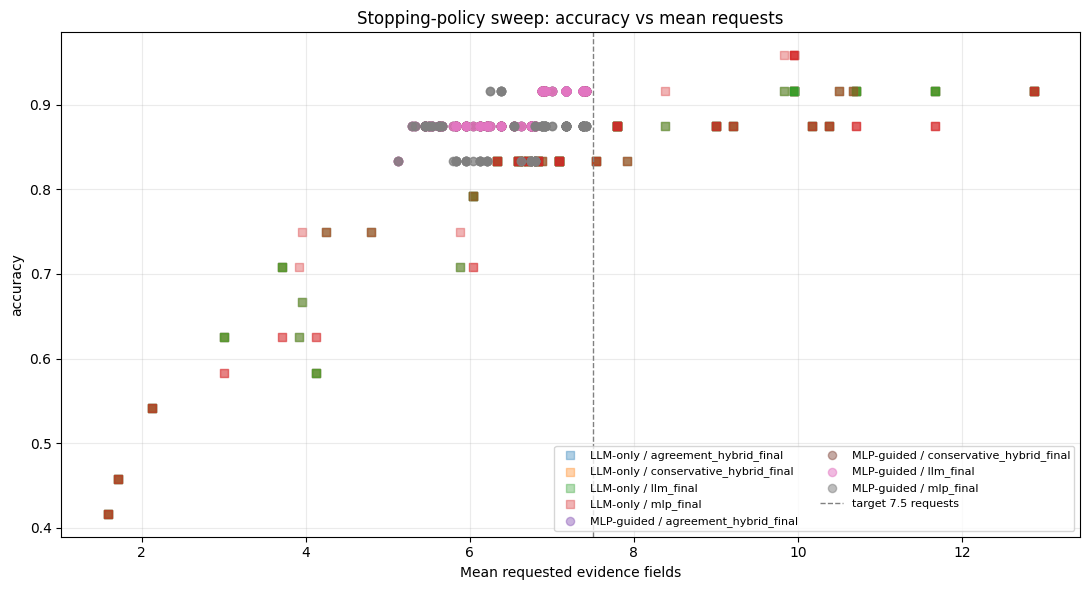

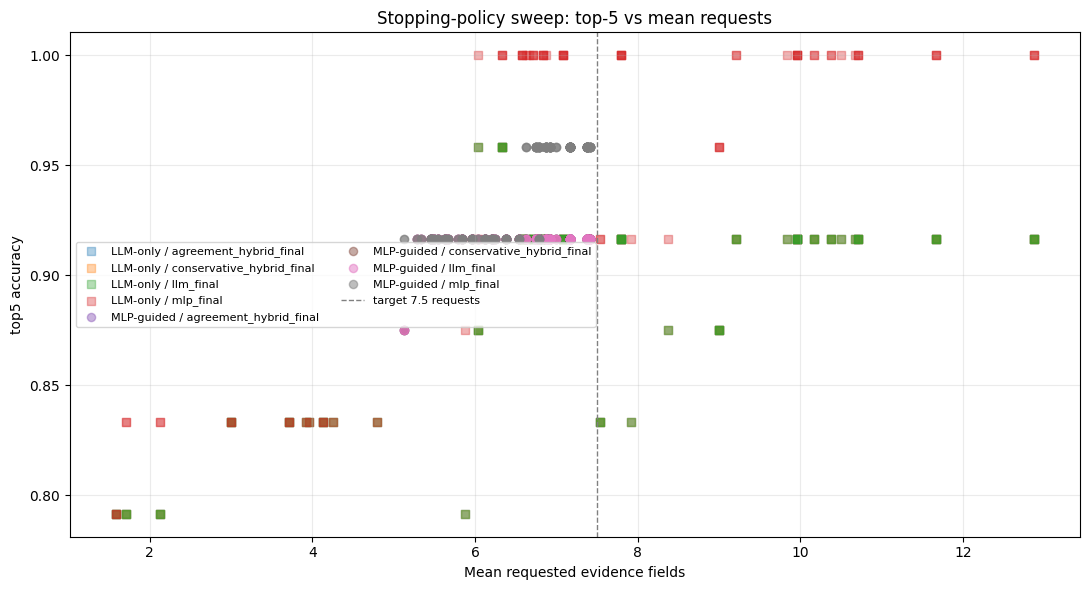

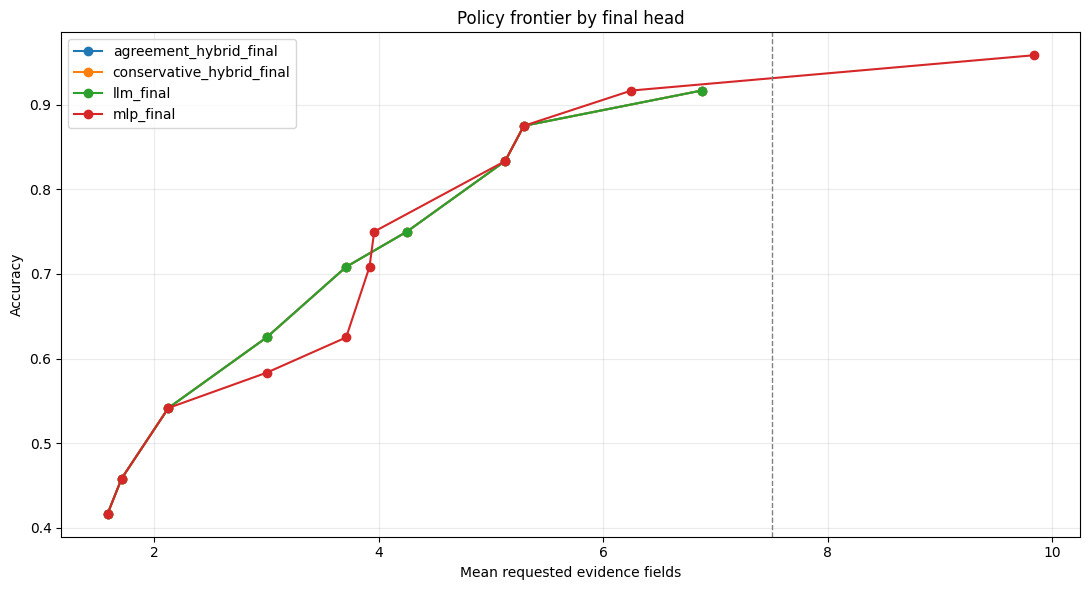

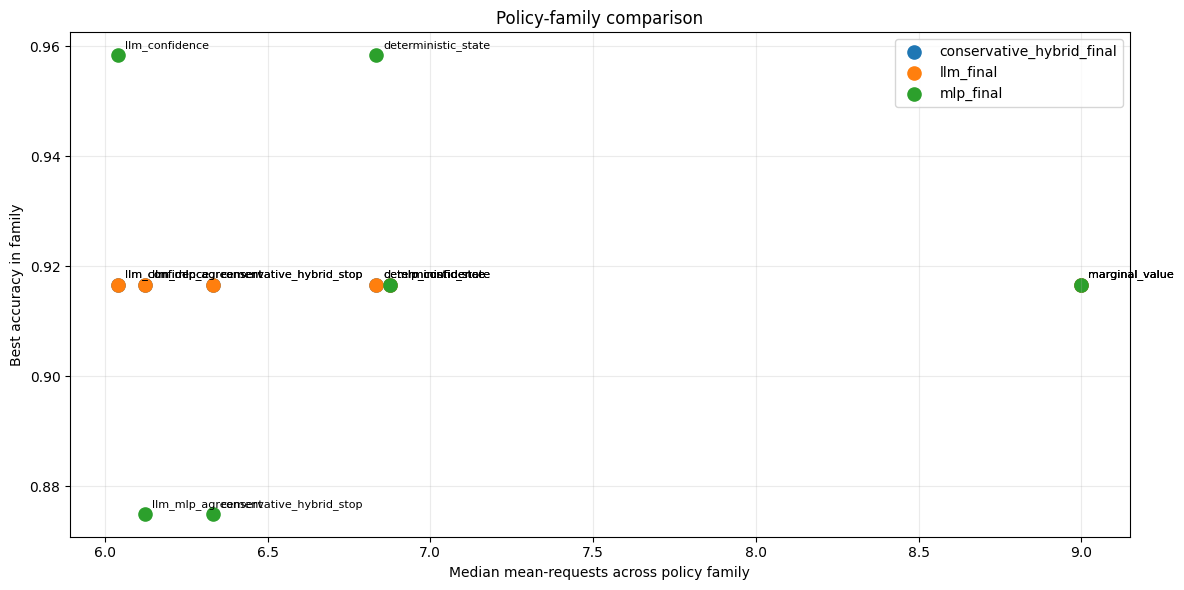

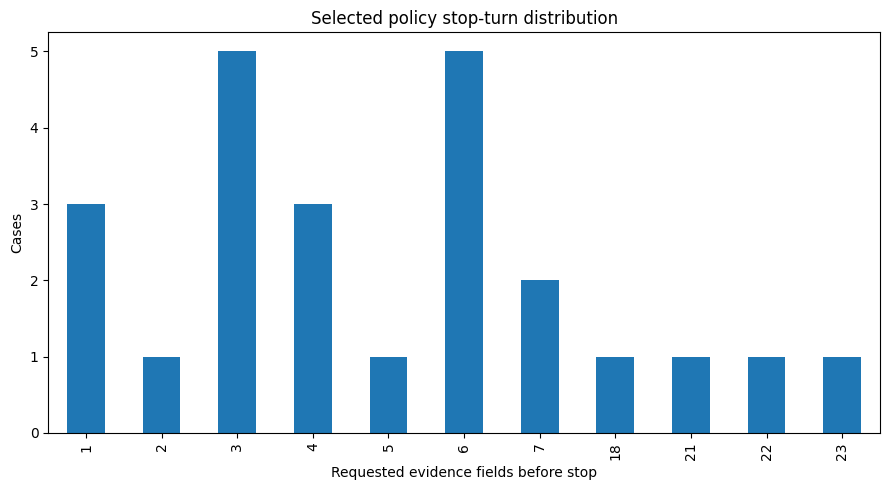

In [10]:
def plot_summary_scatter(summary: pd.DataFrame, y_col: str, title: str, filename: str) -> None:
    plt.figure(figsize=(11, 6))
    for (uses_mlp, final_head), group in summary.groupby(["uses_mlp_signal", "final_head"]):
        label = ("MLP-guided" if uses_mlp else "LLM-only") + f" / {final_head}"
        marker = "o" if uses_mlp else "s"
        alpha = 0.50 if uses_mlp else 0.35
        plt.scatter(group["mean_requests"], group[y_col], s=35, alpha=alpha, marker=marker, label=label)
    plt.axvline(TARGET_MEAN_REQUESTS, linestyle="--", color="gray", linewidth=1, label=f"target {TARGET_MEAN_REQUESTS:g} requests")
    plt.xlabel("Mean requested evidence fields")
    plt.ylabel(y_col.replace("_", " "))
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=180)
    plt.show()


plot_summary_scatter(policy_sweep_summary, "accuracy", "Stopping-policy sweep: accuracy vs mean requests", "accuracy_vs_mean_requests.png")
plot_summary_scatter(policy_sweep_summary, "top5_accuracy", "Stopping-policy sweep: top-5 vs mean requests", "top5_vs_mean_requests.png")

plt.figure(figsize=(11, 6))
for final_head, group in policy_frontier.groupby("final_head"):
    plt.plot(group["mean_requests"], group["accuracy"], marker="o", label=final_head)
plt.axvline(TARGET_MEAN_REQUESTS, linestyle="--", color="gray", linewidth=1)
plt.xlabel("Mean requested evidence fields")
plt.ylabel("Accuracy")
plt.title("Policy frontier by final head")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "policy_frontier_accuracy.png", dpi=180)
plt.show()

family_summary = (
    policy_sweep_summary.groupby(["policy_family", "uses_mlp_signal", "final_head"])
    .agg(best_accuracy=("accuracy", "max"), best_top5=("top5_accuracy", "max"), min_requests=("mean_requests", "min"), median_requests=("mean_requests", "median"))
    .reset_index()
)
family_summary.to_csv(ARTIFACT_ROOT / "policy_family_summary.csv", index=False)
plt.figure(figsize=(12, 6))
plot_frame = family_summary[family_summary["final_head"].isin(["llm_final", "mlp_final", "conservative_hybrid_final"])]
for final_head, group in plot_frame.groupby("final_head"):
    plt.scatter(group["median_requests"], group["best_accuracy"], s=90, label=final_head)
    for row in group.itertuples(index=False):
        plt.annotate(row.policy_family, (row.median_requests, row.best_accuracy), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel("Median mean-requests across policy family")
plt.ylabel("Best accuracy in family")
plt.title("Policy-family comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "policy_family_comparison.png", dpi=180)
plt.show()

selected_case_results = case_policy_results[
    (case_policy_results["policy_name"] == selected_policy["policy_name"])
].copy()
selected_case_results.to_csv(ARTIFACT_ROOT / "selected_policy_case_results.csv", index=False)
plt.figure(figsize=(9, 5))
selected_case_results["num_requests_before_turn"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Requested evidence fields before stop")
plt.ylabel("Cases")
plt.title("Selected policy stop-turn distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "selected_policy_stop_distribution.png", dpi=180)
plt.show()

## Save Run Config And Brief Interpretation

In [11]:
resolved_run_config = {
    "run_name": RUN_NAME,
    "offline_replay_only": True,
    "no_api_calls": True,
    "main_replay_dir": str(MAIN_REPLAY_DIR),
    "observed_notebook08_run_dir": str(OBSERVED_NB08_RUN_DIR),
    "hybrid_reference_run_dir": str(HYBRID_REFERENCE_RUN_DIR),
    "partial_model_dir": str(partial_model_dir),
    "target_mean_requests": TARGET_MEAN_REQUESTS,
    "num_main_cases": int(len(main_case_ids)),
    "num_turn_feature_rows": int(len(turn_features)),
    "num_policy_specs": int(len(policy_specs)),
    "num_policy_summary_rows": int(len(policy_sweep_summary)),
    "mlp_reconstruction_check": mlp_reconstruction_check,
    "replay_limitation": "Offline replay tests alternative stopping points along saved traces. It cannot test how the LLM would choose different future evidence after an altered stop/continue decision.",
}
with (ARTIFACT_ROOT / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
    json.dump(resolved_run_config, handle, indent=2)

print("Artifacts written to:", ARTIFACT_ROOT)
print("Selected policy:", selected_policy["policy_name"], selected_policy["final_head"])
print("Selected accuracy:", selected_policy["accuracy"], "mean requests:", selected_policy["mean_requests"])
print("Matched-budget comparison:")
display(matched_budget_comparison)

Artifacts written to: /Users/bilalawan/claw/assignments/baseline_model/artifacts/stopping_policy_ablation/stopping_policy_ablation_24case_v1
Selected policy: mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0 agreement_hybrid_final
Selected accuracy: 0.9166666666666666 mean requests: 6.875
Matched-budget comparison:


,comparison_group,policy_family,policy_name,uses_mlp_signal,final_head,policy_params,simplicity_rank,num_cases,mean_requests,median_requests,mean_revealed_root_count,forced_end_rate,rule_stop_rate,target_budget_gap,correct_count,accuracy,top3_accuracy,top5_accuracy,macro_f1
0,best_llm_only_stopping__llm_final,deterministic_state,det_margin_ge_0.80_unres_le_0.20,False,llm_final,"{""margin_min"": 0.8, ""min_requests"": 1, ""stability_min"": 1, ""unresolved_max"": 0.2}",2,24,6.333333,3.0,7.333333,0.000000,1.000000,1.166667,20,0.833333,0.916667,0.958333,0.766667
1,best_mlp_guided_stopping__llm_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,llm_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667
2,best_mlp_guided_stopping__mlp_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.35_stab_2,True,mlp_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.35, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 2}",2,24,6.250000,5.0,7.250000,0.000000,1.000000,1.250000,22,0.916667,0.916667,0.916667,0.866667
3,best_mlp_guided_stopping__conservative_hybrid_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,conservative_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667
4,best_mlp_guided_stopping__agreement_hybrid_final,mlp_confidence,mlp_conf_ge_0.70_margin_ge_0.20_entropy_le_0.10_stab_0,True,agreement_hybrid_final,"{""min_requests"": 1, ""mlp_confidence_min"": 0.7, ""mlp_entropy_max"": 0.1, ""mlp_margin_min"": 0.2, ""mlp_stability_min"": 0}",2,24,6.875000,4.5,7.875000,0.083333,0.916667,0.625000,22,0.916667,0.916667,0.916667,0.866667
